In [2]:
from google.colab import files
upload=files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [7]:
import pandas as pd
df=pd.read_csv("agriculture_yield_dataset.csv")

In [14]:
print("rows and columns:",df.shape)
print(df.columns)
print(df.head(10))

rows and columns: (1500, 8)
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3          

In [17]:
print(df.dtypes)
print()
print(df.isnull().sum())

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [26]:
print("stats:\n",df.describe())
print("\nhighest mean:")
stats=df.describe()
print(stats.loc['mean'].idxmax())
print("\nhighest standard deviation:")
print(stats.loc['std'].idxmax())

stats:
        rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max      

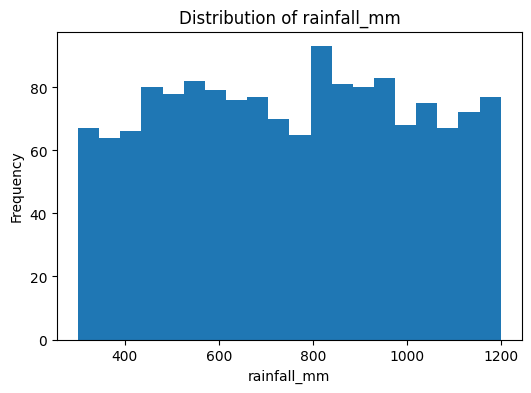

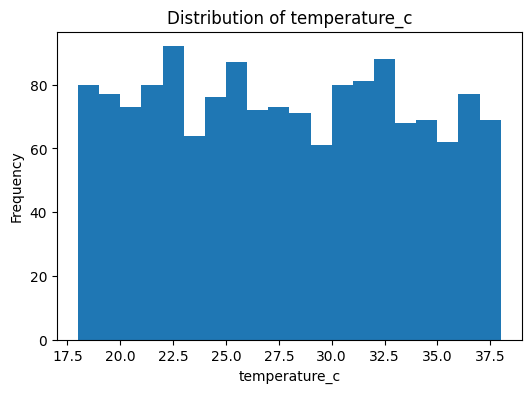

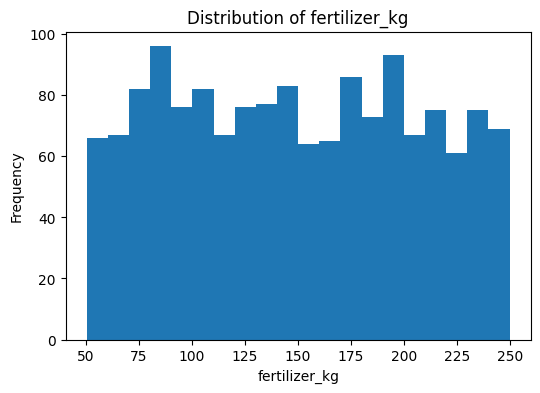

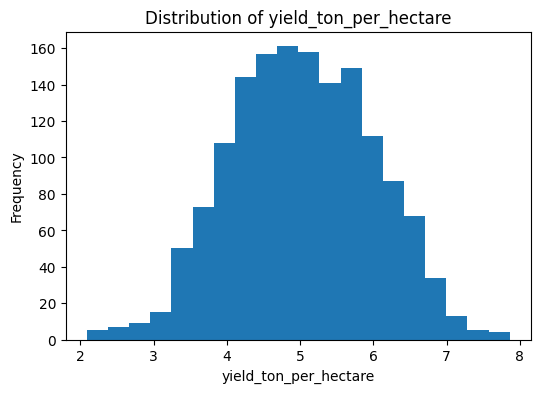

In [29]:
import matplotlib.pyplot as plt
columns=['rainfall_mm','temperature_c','fertilizer_kg','yield_ton_per_hectare']
for c in columns:
  plt.figure(figsize=(6,4))
  plt.hist(df[c],bins=20)
  plt.title(f'Distribution of {c}')
  plt.xlabel(c)
  plt.ylabel('Frequency')
  plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


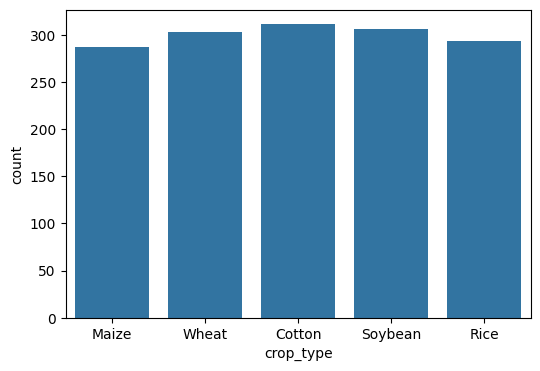

Cotton


In [32]:
import seaborn as sns
print(df['crop_type'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='crop_type',data=df)
plt.show()
print(df['crop_type'].value_counts().idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


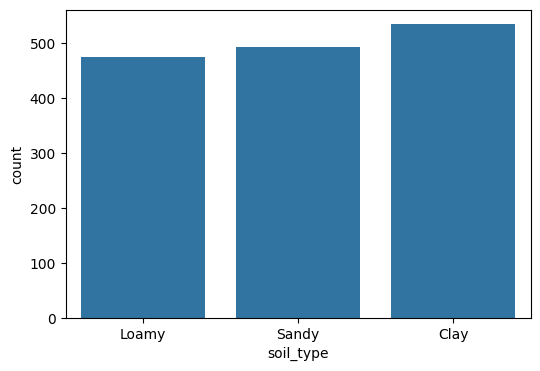

Clay


In [34]:
print(df['soil_type'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='soil_type',data=df)
plt.show()
print(df['soil_type'].value_counts().idxmax())

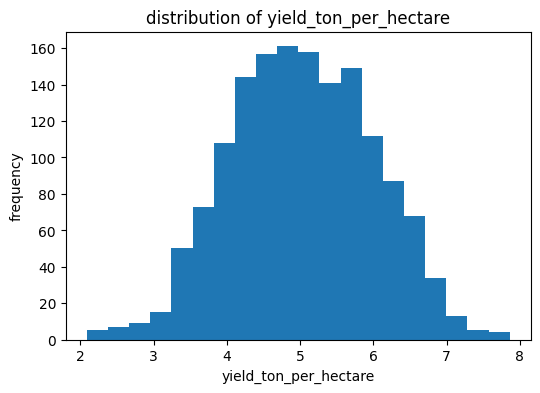

In [36]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'],bins=20)
plt.xlabel('yield_ton_per_hectare')
plt.ylabel('frequency')
plt.title('distribution of yield_ton_per_hectare')
plt.show()

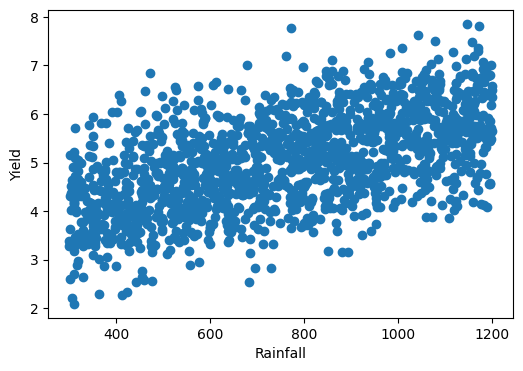

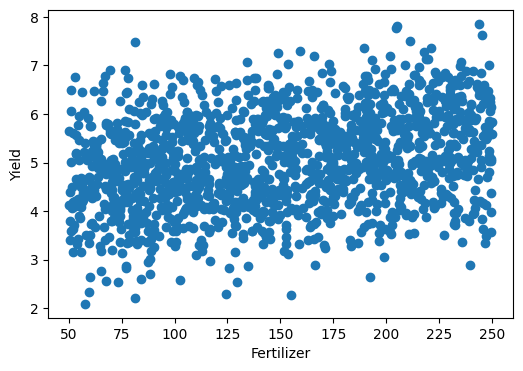

In [37]:
plt.figure(figsize=(6,4))
plt.scatter(df['rainfall_mm'],
            df['yield_ton_per_hectare'])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['fertilizer_kg'],
            df['yield_ton_per_hectare'])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()


                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

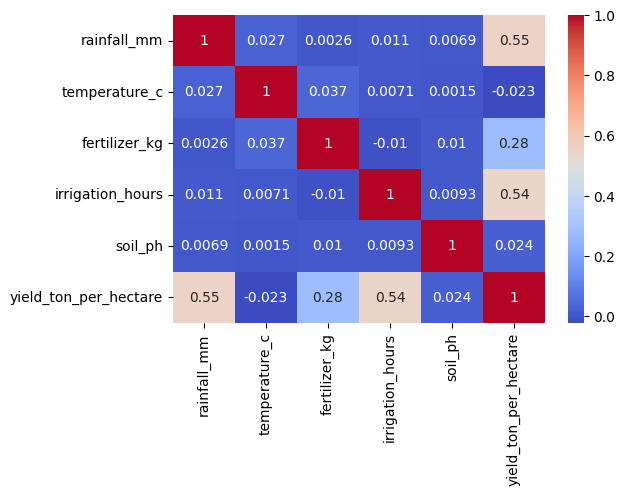

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [43]:
import numpy as np
numerical_df=df.select_dtypes(include=np.number)
corr_matrix=numerical_df.corr()
print(corr_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.show()

yield_corr=corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)
print(yield_corr)

In [44]:
crop_avg=df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print(crop_avg)
soil_avg=df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print(soil_avg)
print("\nbest crop:",crop_avg.idxmax())
print("\nbest soil:",soil_avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

best crop: Rice

best soil: Loamy


In [47]:
from sklearn.preprocessing import OneHotEncoder
categorical_cols=df.select_dtypes(include='object').columns
print(categorical_cols)
encoded_df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)
print(encoded_df.head())

Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat

In [49]:
target='yield_ton_per_hectare'
X=encoded_df.drop(target,axis=1)
y=encoded_df[target]
print(target)

yield_ton_per_hectare


In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [52]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print("intercept:",model.intercept_)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coef_df)

print("\nHighest Positive Coefficient:")
print(
    coef_df.sort_values(
        by='Coefficient',
        ascending=False
    ).head(1)
)

intercept: 1.587132027736121
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Highest Positive Coefficient:
          Feature  Coefficient
6  crop_type_Rice     0.863993
